In [1]:
# Cell 1 — Title
# ============================================================
# NOTEBOOK 02 — EXPLORATORY DATA ANALYSIS (EDA)
# Stage 3: Memory Feature Collection Layer
# Purpose: Understand distributions, class balance, correlations
# ============================================================

In [3]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

PLOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
RAW_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'raw', 'Obfuscated-MalMem2022.csv'))

df = pd.read_csv(RAW_PATH)
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (58596, 57)


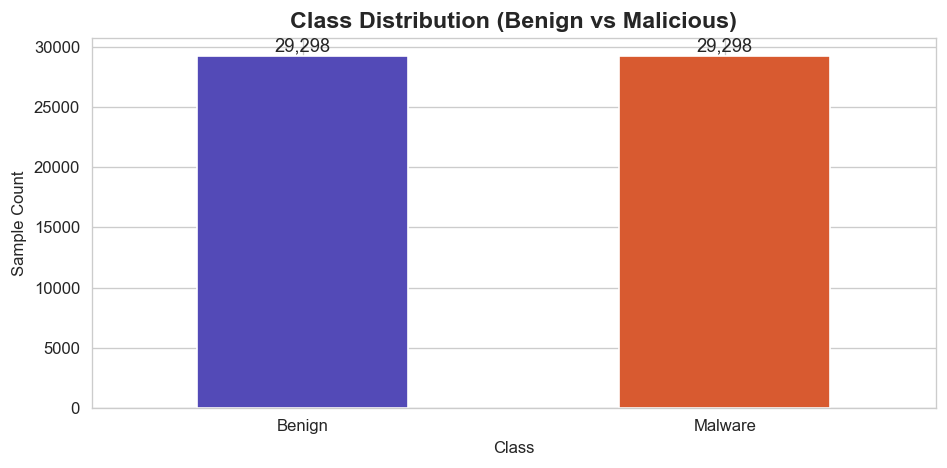

Saved: class_distribution.png


In [6]:
# Cell 3 — Class distribution plot
plt.figure(figsize=(8, 4))
ax = df['Class'].value_counts().plot(kind='bar', color=['#534AB7','#D85A30'], edgecolor='white', width=0.5)
plt.title('Class Distribution (Benign vs Malicious)', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print("Saved: class_distribution.png")

C:\Users\aryar\AppData\Local\Temp\ipykernel_27968\1020075172.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


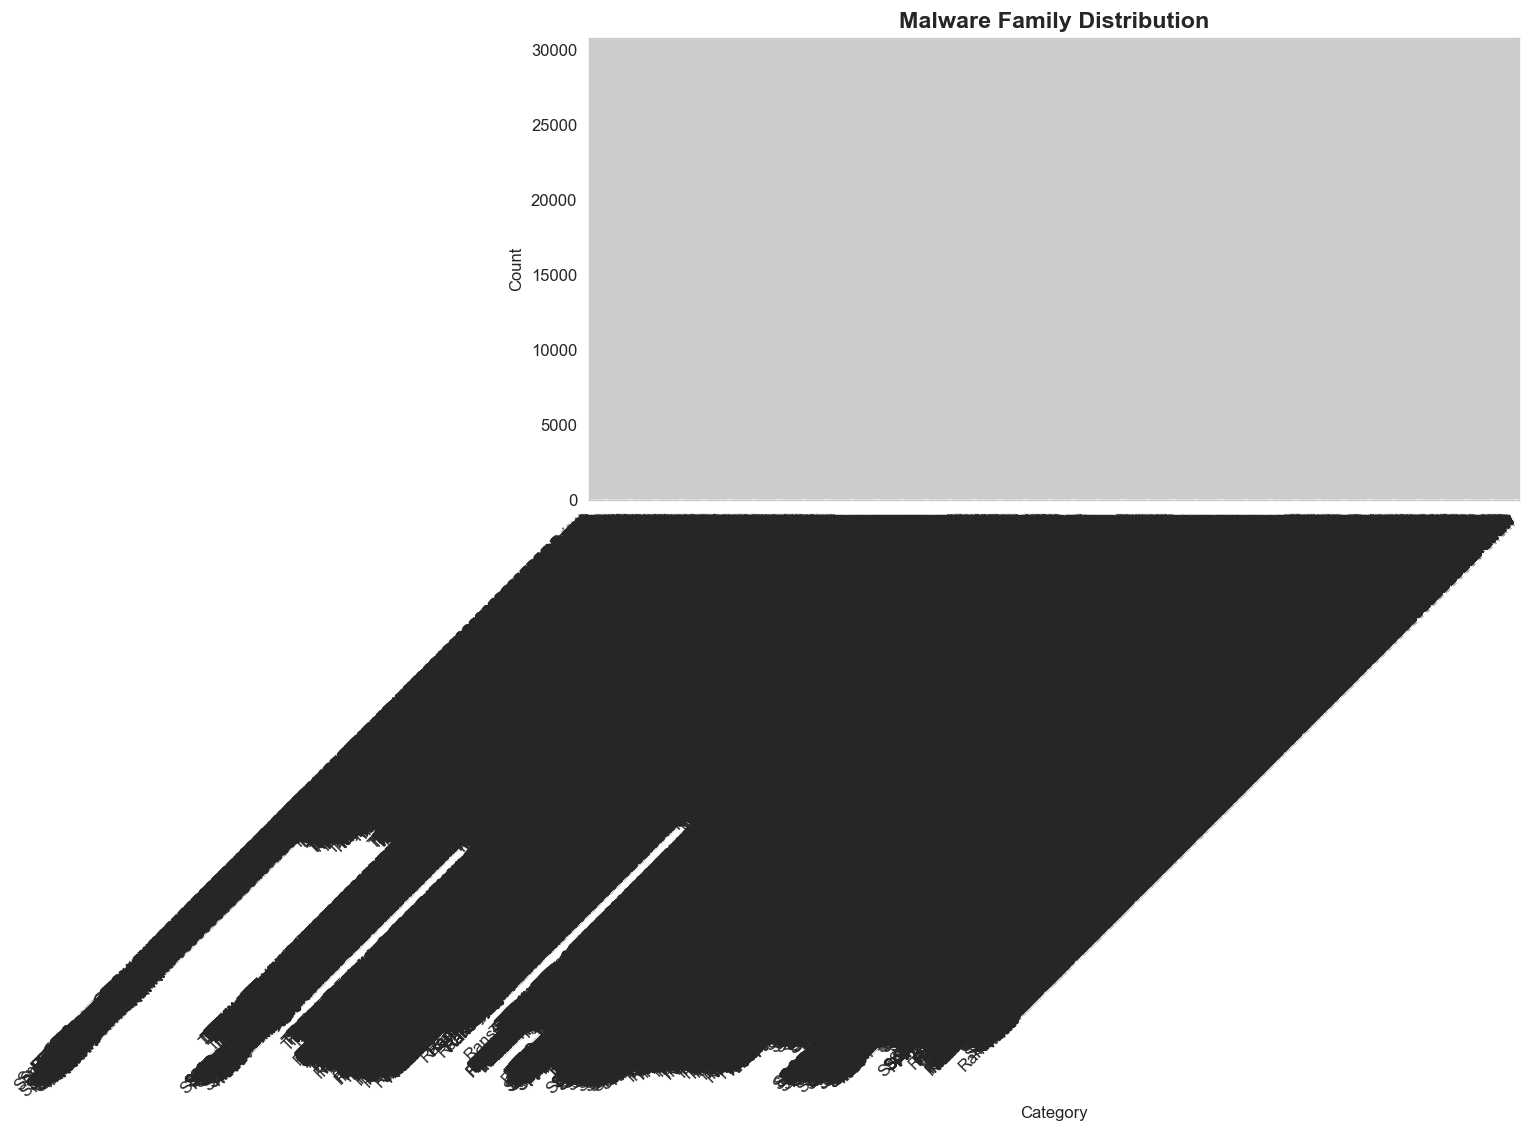

In [7]:
# Cell 4 — Category distribution (malware families)
plt.figure(figsize=(10, 5))
category_counts = df['Category'].value_counts()
colors = ['#534AB7','#D85A30','#0F6E56','#854F0B','#993C1D',
          '#185FA5','#3B6D11','#993556','#5F5E5A','#A32D2D']
category_counts.plot(kind='bar', color=colors[:len(category_counts)], edgecolor='white', width=0.6)
plt.title('Malware Family Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'category_distribution.png'), dpi=150)
plt.show()

In [8]:
# Cell 5 — Separate numeric columns for analysis
# Drop non-numeric and label columns
label_cols = ['Category', 'Class']
numeric_df = df.drop(columns=label_cols).select_dtypes(include=[np.number])
print(f"Numeric feature columns: {numeric_df.shape[1]}")
print(numeric_df.columns.tolist())

Numeric feature columns: 55
['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread

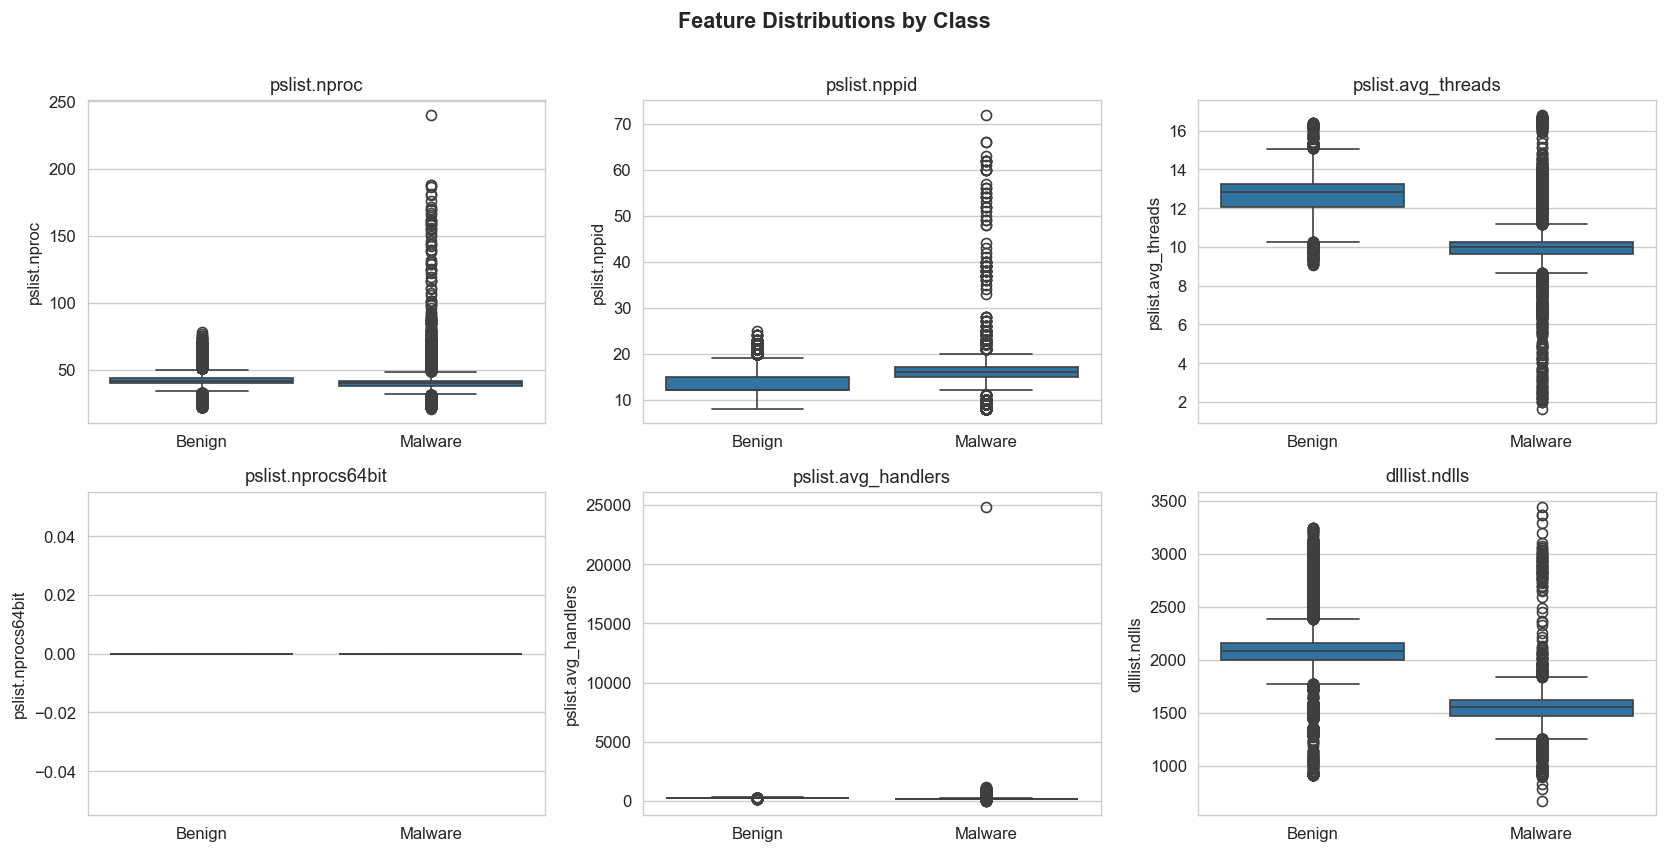

In [9]:
# Cell 6 — Distribution of top 6 features (box plots)
top_features = numeric_df.columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(x=df['Class'], y=df[feat], ax=axes[i],
                palette={0:'#534AB7', 1:'#D85A30'} if df['Class'].dtype != object else None)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

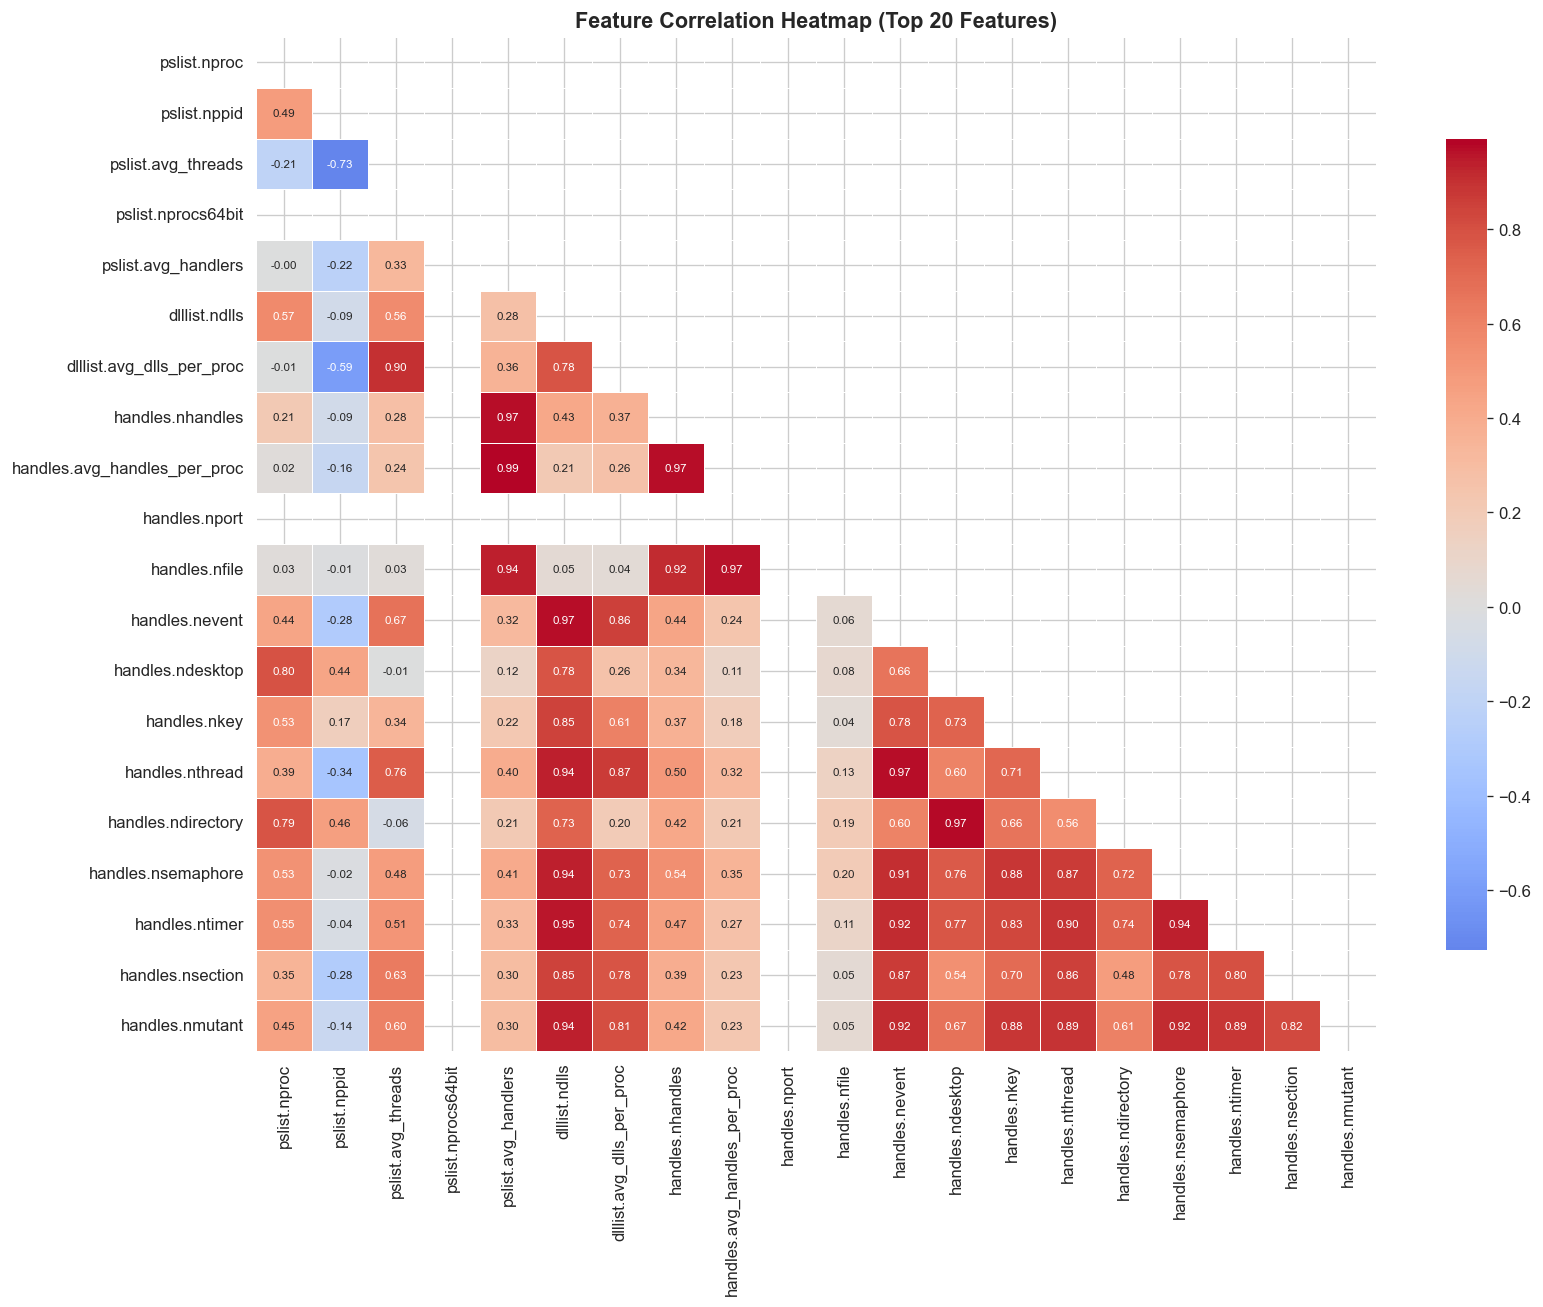

In [10]:
# Cell 7 — Correlation heatmap (top 20 features)
corr_features = numeric_df.iloc[:, :20]
corr_matrix = corr_features.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (Top 20 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 8 — Check class balance percentage
total = len(df)
class_counts = df['Class'].value_counts()
print("Class Balance:\n")
for cls, count in class_counts.items():
    print(f"  Class {cls}: {count:,} samples ({count/total*100:.1f}%)")
print(f"\nTotal samples: {total:,}")

Class Balance:

  Class Benign: 29,298 samples (50.0%)
  Class Malware: 29,298 samples (50.0%)

Total samples: 58,596


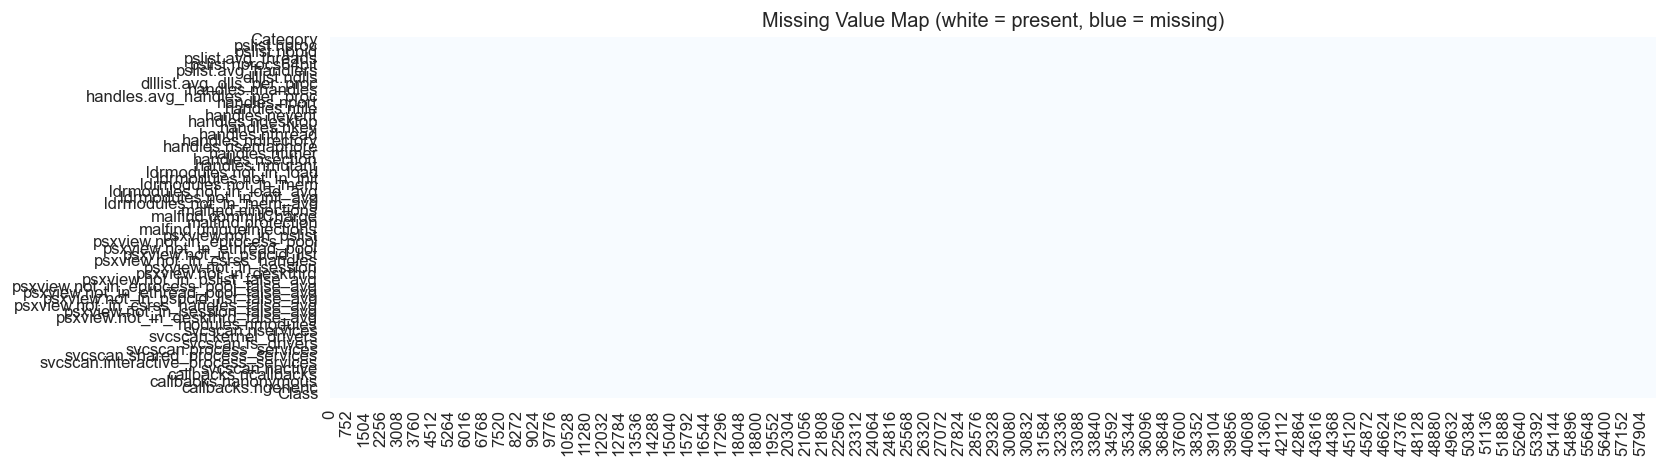

In [12]:
# Cell 9 — Missing value heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='Blues')
plt.title('Missing Value Map (white = present, blue = missing)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'missing_value_map.png'), dpi=150)
plt.show()

In [13]:
# Cell 10 — EDA summary
print("EDA Summary")
print("=" * 40)
print(f"Total samples     : {df.shape[0]:,}")
print(f"Total features    : {numeric_df.shape[1]}")
print(f"Missing values    : {df.isnull().sum().sum()}")
print(f"Classes           : {df['Class'].nunique()}")
print(f"Malware families  : {df['Category'].nunique()}")
print()
print("Key observations:")
print("  - Check if dataset is balanced from Cell 8 output")
print("  - High correlation features are candidates for removal")
print("  - Outliers visible in box plots need handling in preprocessing")
print("\nNotebook 02 complete. Proceed to 03_preprocessing.ipynb")

EDA Summary
Total samples     : 58,596
Total features    : 55
Missing values    : 0
Classes           : 2
Malware families  : 28346

Key observations:
  - Check if dataset is balanced from Cell 8 output
  - High correlation features are candidates for removal
  - Outliers visible in box plots need handling in preprocessing

Notebook 02 complete. Proceed to 03_preprocessing.ipynb
